In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

DATA = Path("/content/drive/MyDrive/dirisa-sdc/processed")

print("DATA path exists:", DATA.exists())
print()
for f in sorted(DATA.glob("*.csv")):
    print("  ", f.name)

DATA path exists: True

   clean_census_population.csv
   clean_district_youth_history.csv
   clean_master_municipality.csv
   clean_provincial_turnout_2021.csv
   clean_youth_registration.csv
   district_trend.csv
   municipality_features.csv
   municipality_widest_gap.csv
   priority_municipalities.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

CHARTS = Path("/content/drive/MyDrive/dirisa-sdc/processed/charts")
CHARTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA / "municipality_features.csv")
priority = pd.read_csv(DATA / "priority_municipalities.csv")
trend = pd.read_csv(DATA / "district_trend.csv")

print("Features shape:", df.shape)
print("Priority shape:", priority.shape)
print("Trend shape:", trend.shape)

Features shape: (33, 30)
Priority shape: (33, 7)
Trend shape: (6, 5)


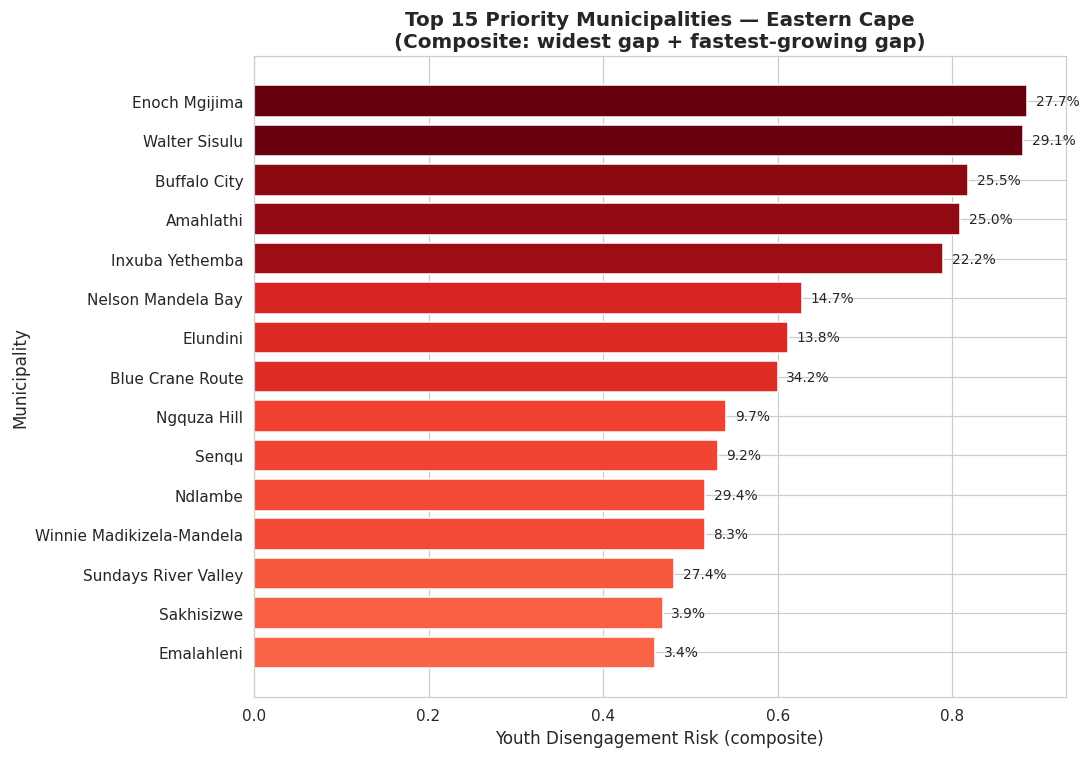

In [4]:
# Chart 1: Top 15 priority municipalities by composite risk
top15 = priority.head(15).sort_values("youth_disengagement_risk")

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top15["municipality"],
    top15["youth_disengagement_risk"],
    color=plt.cm.Reds(top15["youth_disengagement_risk"] / top15["youth_disengagement_risk"].max())
)

ax.set_xlabel("Youth Disengagement Risk (composite)", fontsize=11)
ax.set_ylabel("Municipality", fontsize=11)
ax.set_title("Top 15 Priority Municipalities — Eastern Cape\n(Composite: widest gap + fastest-growing gap)",
             fontsize=13, fontweight="bold")

for bar, gap in zip(bars, top15["youth_gap_2026"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{gap:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(CHARTS / "01_priority_municipalities.png", bbox_inches="tight")
plt.show()

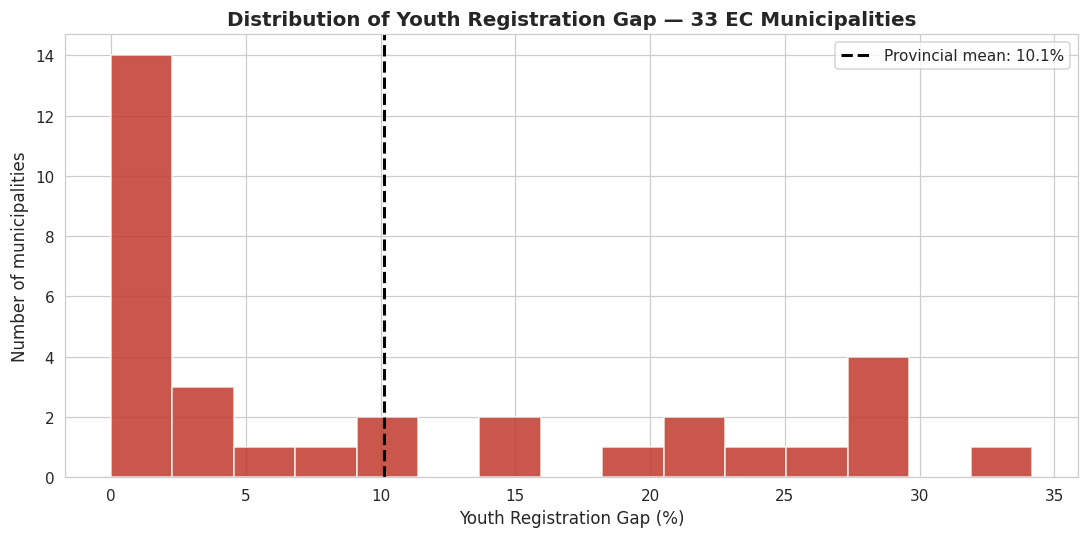

In [5]:
# Chart 2: Distribution of youth registration gap
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df["youth_gap_2026"] * 100, bins=15,
        color="#c0392b", edgecolor="white", alpha=0.85)

mean_gap = df["youth_gap_2026"].mean() * 100
ax.axvline(mean_gap, color="black", linestyle="--", linewidth=2,
           label=f"Provincial mean: {mean_gap:.1f}%")

ax.set_xlabel("Youth Registration Gap (%)", fontsize=11)
ax.set_ylabel("Number of municipalities", fontsize=11)
ax.set_title("Distribution of Youth Registration Gap — 33 EC Municipalities",
             fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(CHARTS / "02_gap_distribution.png", bbox_inches="tight")
plt.show()

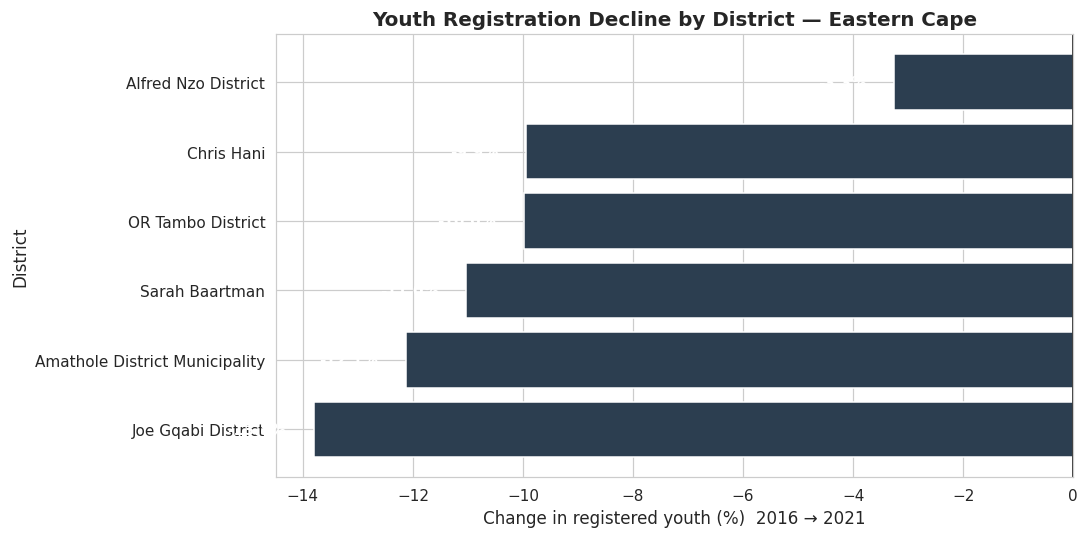

In [6]:
# Chart 3: District youth registration trend 2016 -> 2021
trend_sorted = trend.sort_values("youth_registration_change_pct")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    trend_sorted["district_municipality"],
    trend_sorted["youth_registration_change_pct"],
    color="#2c3e50"
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Change in registered youth (%)  2016 → 2021", fontsize=11)
ax.set_ylabel("District", fontsize=11)
ax.set_title("Youth Registration Decline by District — Eastern Cape",
             fontsize=13, fontweight="bold")

for bar, val in zip(bars, trend_sorted["youth_registration_change_pct"]):
    ax.text(val - 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", ha="right",
            color="white", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig(CHARTS / "03_district_trend.png", bbox_inches="tight")
plt.show()

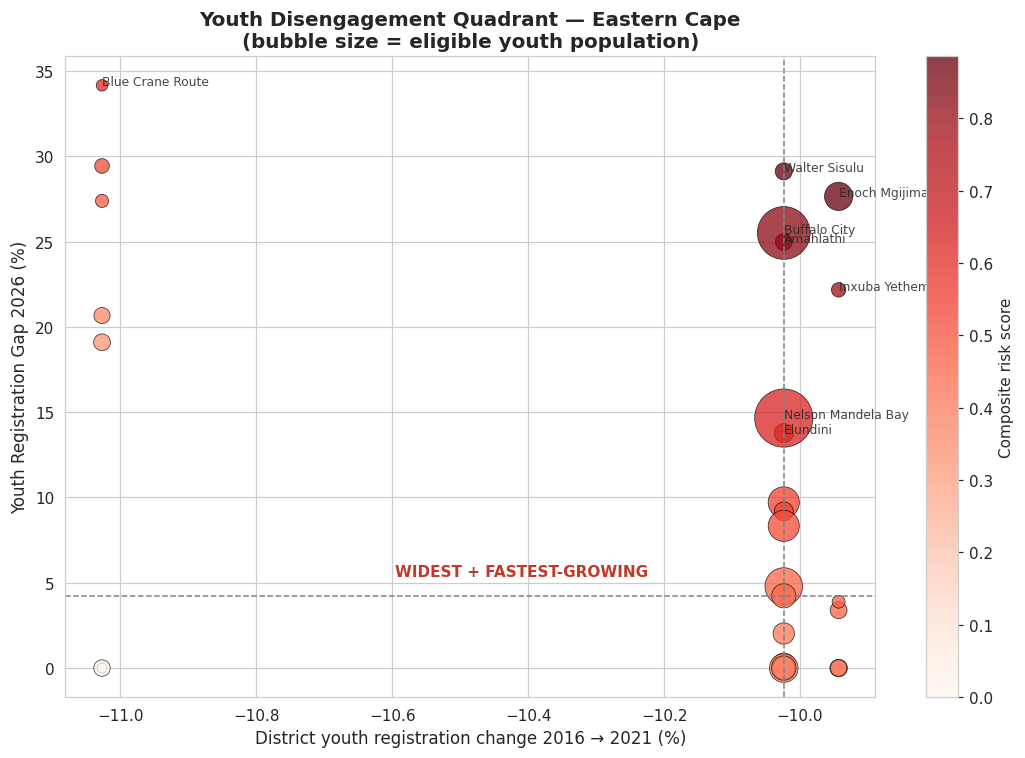

In [7]:
# Chart 4: Gap vs district trend — quadrant plot
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df["youth_registration_change_pct"],
    df["youth_gap_2026"] * 100,
    s=df["youth_pop_20_34_2022"] / 200,
    c=df["youth_disengagement_risk"],
    cmap="Reds",
    alpha=0.75,
    edgecolors="black",
    linewidth=0.5
)

x_med = df["youth_registration_change_pct"].median()
y_med = df["youth_gap_2026"].median() * 100
ax.axvline(x_med, color="grey", linestyle="--", linewidth=1)
ax.axhline(y_med, color="grey", linestyle="--", linewidth=1)

ax.text(x_med - 0.2, y_med + 1, "WIDEST + FASTEST-GROWING",
        fontsize=10, fontweight="bold", color="#c0392b",
        ha="right", va="bottom")

for _, row in priority.head(8).iterrows():
    ax.annotate(
        row["municipality"],
        (row["youth_registration_change_pct"], row["youth_gap_2026"] * 100),
        fontsize=8, alpha=0.85
    )

ax.set_xlabel("District youth registration change 2016 → 2021 (%)", fontsize=11)
ax.set_ylabel("Youth Registration Gap 2026 (%)", fontsize=11)
ax.set_title("Youth Disengagement Quadrant — Eastern Cape\n(bubble size = eligible youth population)",
             fontsize=13, fontweight="bold")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Composite risk score", fontsize=10)

plt.tight_layout()
plt.savefig(CHARTS / "04_gap_vs_trend_quadrant.png", bbox_inches="tight")
plt.show()

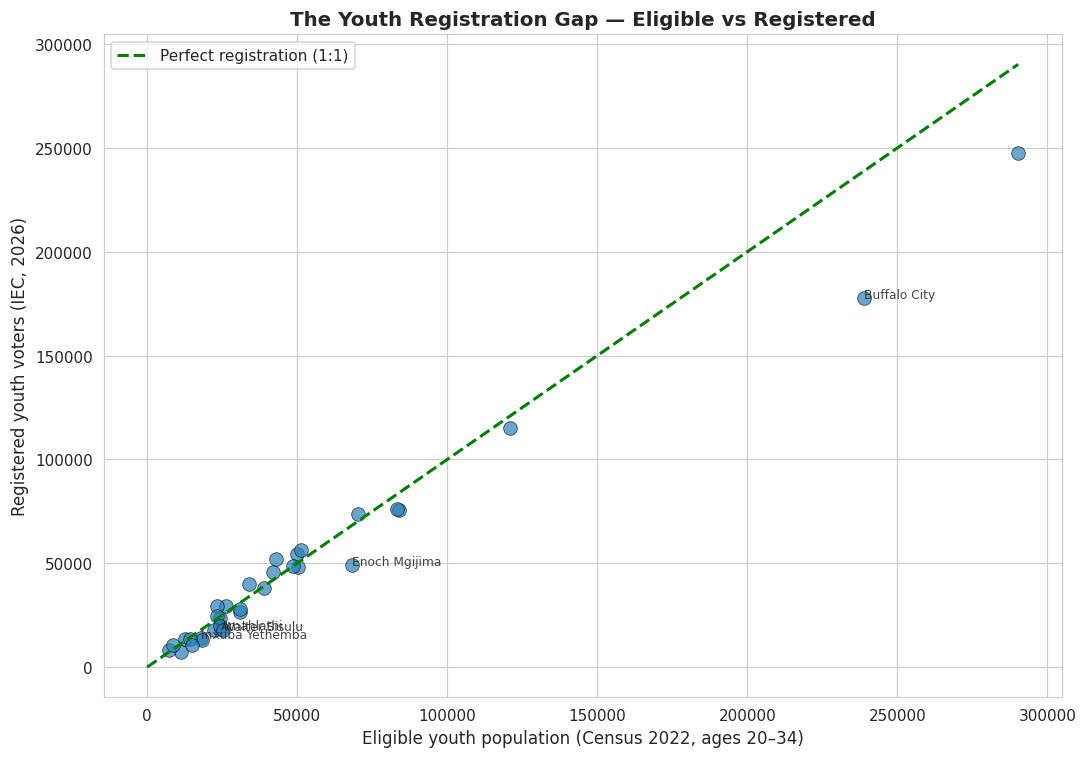

In [9]:
# Chart 5: Eligible youth vs Registered youth
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    df["youth_pop_20_34_2022"],
    df["registered_youth_total"],
    s=80, color="#2980b9", alpha=0.7, edgecolors="black", linewidth=0.5
)

max_val = max(df["youth_pop_20_34_2022"].max(), df["registered_youth_total"].max())
ax.plot([0, max_val], [0, max_val], color="green", linestyle="--",
        linewidth=2, label="Perfect registration (1:1)")

# Annotate the top 5 municipalities from `df` that are in the priority list
top5_codes = priority.head(5)["mdb_code"].tolist()
for _, row in df[df["mdb_code"].isin(top5_codes)].iterrows():
    ax.annotate(
        row["municipality"],
        (row["youth_pop_20_34_2022"], row["registered_youth_total"]),
        fontsize=8, alpha=0.85
    )

ax.set_xlabel("Eligible youth population (Census 2022, ages 20–34)", fontsize=11)
ax.set_ylabel("Registered youth voters (IEC, 2026)", fontsize=11)
ax.set_title("The Youth Registration Gap — Eligible vs Registered",
             fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(CHARTS / "05_eligible_vs_registered.png", bbox_inches="tight")
plt.show()

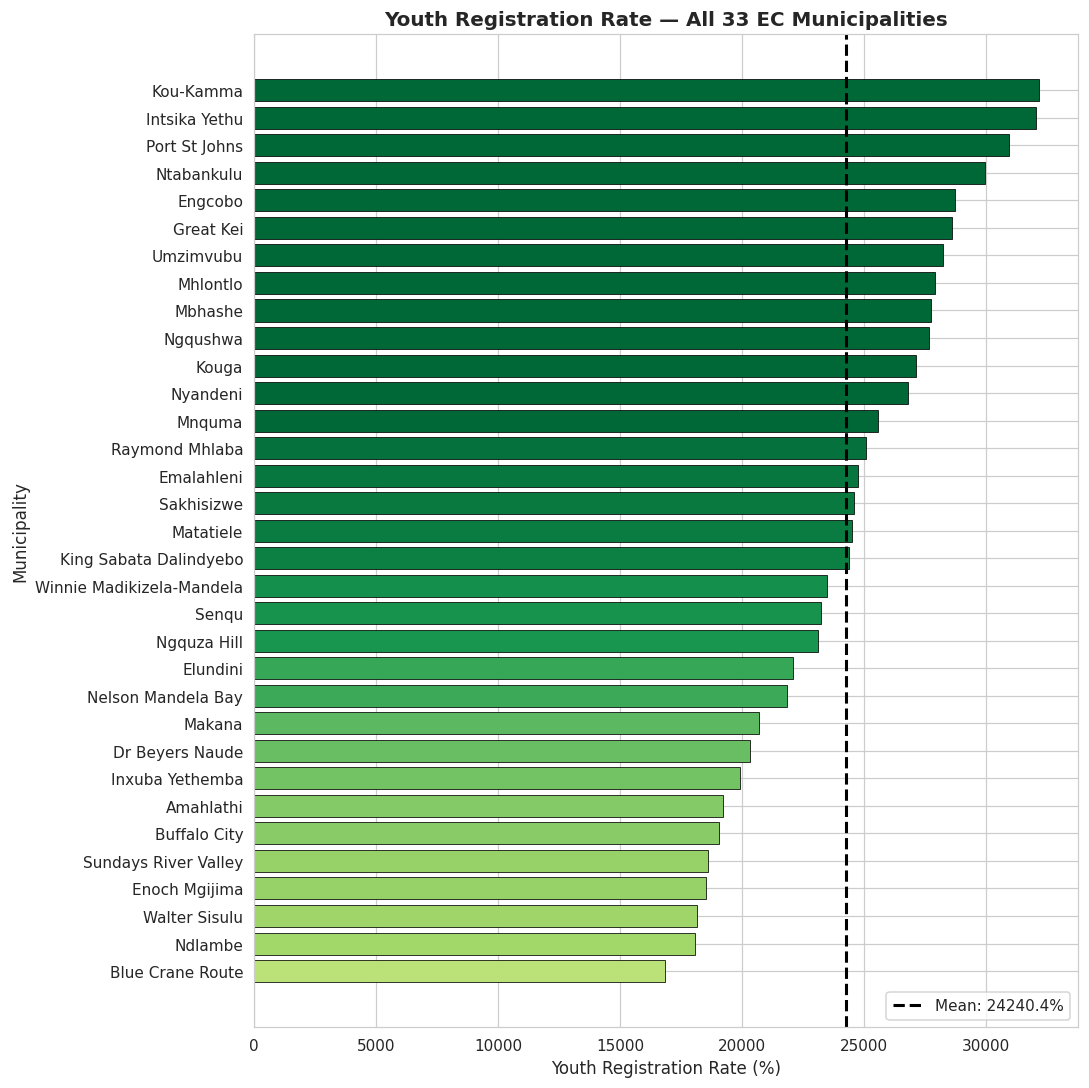

In [10]:
# Chart 6: Youth registration rate ranked (2026)
rate_sorted = df.sort_values("youth_registration_rate_2026", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = plt.cm.RdYlGn(rate_sorted["youth_registration_rate_2026"])

bars = ax.barh(
    rate_sorted["municipality"],
    rate_sorted["youth_registration_rate_2026"] * 100,
    color=colors, edgecolor="black", linewidth=0.5
)

ax.axvline(rate_sorted["youth_registration_rate_2026"].mean() * 100,
           color="black", linestyle="--", linewidth=2,
           label=f"Mean: {rate_sorted['youth_registration_rate_2026'].mean():.1%}")

ax.set_xlabel("Youth Registration Rate (%)", fontsize=11)
ax.set_ylabel("Municipality", fontsize=11)
ax.set_title("Youth Registration Rate — All 33 EC Municipalities",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(CHARTS / "06_registration_rate_ranked.png", bbox_inches="tight")
plt.show()

In [11]:
print("Charts saved to:", CHARTS)
for f in sorted(CHARTS.glob("*.png")):
    print("  ", f.name)

Charts saved to: /content/drive/MyDrive/dirisa-sdc/processed/charts
   01_priority_municipalities.png
   02_gap_distribution.png
   03_district_trend.png
   04_gap_vs_trend_quadrant.png
   05_eligible_vs_registered.png
   06_registration_rate_ranked.png
